# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [93]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from pygam import LogisticGAM, s, f
from sklearn.tree import DecisionTreeClassifier
# out of all the glms, we choose the poisson - it does not have negative values, and varying variance???
# also we are looking for a scale of values up to 1000...
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pyimpute import impute
from sklearn import model_selection
from elapid import MaxentModel

Run the subprocess, R code to generate pseudo absences. Will be customized depending on the models

In [44]:
command = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
subprocess.run(command, check = True)

CompletedProcess(args=['C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe', 'pseudo_absence.R', 'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', '2', 'northerncorn'], returncode=0)

### Converting shapefiles (.shp) to geopandas dataframe

In [45]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf = gpd.GeoDataFrame.from_file('data/ncr.shp')
ncr_gdf.sample(5)

,CLASS,geometry
114,1.0,POINT (-88.03978 43.793)
565,1.0,POINT (-96.77777 44.27032)
1200,0.0,POINT (-114.97564 46.62786)
200,0.0,POINT (-110.3534 38.35469)
1586,1.0,POINT (-73.34163 44.69491)


Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [46]:
print("Number of duplicates: ", ncr_gdf.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf.crs))
print("{} observations with {} columns".format(*ncr_gdf.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
2122 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

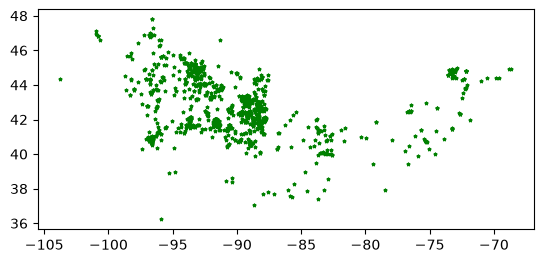

In [47]:
ncr_gdf[ncr_gdf.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

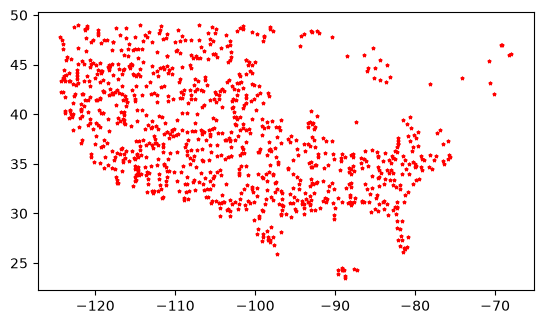

In [48]:
ncr_gdf[ncr_gdf.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [ ]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
    'worldclim/wc2.1_2.5m_bio_*.tif'))

# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(ras_feats), ' raster features.')
print(ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6


There are  7  raster features.
['worldclim\\wc2.1_2.5m_bio_13.tif', 'worldclim\\wc2.1_2.5m_bio_14.tif', 'worldclim\\wc2.1_2.5m_bio_15.tif', 'worldclim\\wc2.1_2.5m_bio_2.tif', 'worldclim\\wc2.1_2.5m_bio_4.tif', 'worldclim\\wc2.1_2.5m_bio_5.tif', 'worldclim\\wc2.1_2.5m_bio_6.tif']


In [ ]:
import rasterio

with rasterio.open(ras_feats[0]) as src:
    raster_crs = src.crs

ncr_gdf = ncr_gdf.to_crs(raster_crs)
 
print(ncr_gdf.crs)


GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


Generate raster maps of suitability. Also separate test sets from the rest for cross validation

In [78]:
from pyimpute import load_training_vector
from pyimpute import load_targets
import numpy as np
import pandas as pd

train_xs, train_ys = load_training_vector(ncr_gdf, ras_feats, response_field='CLASS')

x_df = pd.DataFrame(train_xs)
x_df = x_df.apply(pd.to_numeric, errors="coerce")
x_df = x_df.replace([np.inf, -np.inf], np.nan)

y_ser = pd.Series(train_ys)

mask = x_df.notna().all(axis=1) & y_ser.notna()

# Apply mask to both X and y
train_xs_clean = x_df.loc[mask].to_numpy(dtype=float)
train_ys_clean = y_ser.loc[mask].to_numpy()

print("Original samples:", len(train_xs))
print("Clean samples:", len(train_xs_clean))
print("Dropped samples:", len(train_xs) - len(train_xs_clean))


train_x, test_x, train_y, test_y = model_selection.train_test_split(train_xs_clean, train_ys_clean, test_size=0.25, random_state=42, stratify=train_ys_clean)
# train_xs.shape, train_ys.shape
train_x.shape, test_x.shape, train_y.shape, test_y.shape

Original samples: 2122
Clean samples: 2110
Dropped samples: 12


((1582, 7), (528, 7), (1582,), (528,))

In [53]:
print(train_x)

[[106.0 18.0 50.184818267822266 ... 1194.714599609375 28.31999969482422
  -16.148000717163086]
 [44.0 14.0 39.32875061035156 ... 661.2297973632812 26.884000778198242
  -8.020000457763672]
 [39.0 14.0 24.457035064697266 ... 827.3080444335938 30.355998992919922
  -8.184000015258789]
 ...
 [123.0 20.0 50.83719253540039 ... 1155.7020263671875 29.299999237060547
  -13.947999954223633]
 [173.0 81.0 18.100406646728516 ... 668.1414184570312 33.20800018310547
  2.871999979019165]
 [91.0 11.0 62.91630554199219 ... 1005.2811889648438 32.992000579833984
  -9.51200008392334]]


Classifier implementation

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score

sample_weights = compute_sample_weight(class_weight='balanced', y=train_y)
k = 4
kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)

### random forest ###

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1)
rf_accuracy_scores = model_selection.cross_val_score(rf, train_x, train_y, cv=kf, scoring='accuracy')
print("rf %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, rf_accuracy_scores.mean() * 100, rf_accuracy_scores.std() * 200))
rf.fit(train_x, train_y)
rf_train_pred = rf.predict(train_x)
rf_test_pred = rf.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, rf_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, rf_test_pred))

### LDA ###

lda = LinearDiscriminantAnalysis()
lda_accuracy_scores = model_selection.cross_val_score(lda, train_x, train_y, cv = kf, scoring='accuracy')
print("lda %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, lda_accuracy_scores.mean() * 100, lda_accuracy_scores.std() * 200))
lda.fit(train_x, train_y)
lda_train_pred = lda.predict(train_x)
lda_test_pred = lda.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, lda_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, lda_test_pred))

### decision tree classifier ###

dtc = DecisionTreeClassifier()
dtc_accuracy_scores = model_selection.cross_val_score(dtc, train_x, train_y, cv = kf, scoring='accuracy')
print("dtc %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, dtc_accuracy_scores.mean() * 100, dtc_accuracy_scores.std() * 200))
dtc.fit(train_x, train_y)
dtc_train_pred = dtc.predict(train_x)
dtc_test_pred = dtc.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, dtc_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, dtc_test_pred))

### logistic regression ###
lr = LogisticRegression(max_iter=5000)
lr_accuracy_scores = model_selection.cross_val_score(lr, train_x, train_y, cv = kf, scoring='accuracy')
print("lr %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, lr_accuracy_scores.mean() * 100, lr_accuracy_scores.std() * 200))
lr.fit(train_x, train_y)
lr_train_pred = lr.predict(train_x)
lr_test_pred = lr.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, lr_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, lr_test_pred))

### xgb classifier ###
xgb = XGBClassifier()
xgb_accuracy_scores = model_selection.cross_val_score(xgb, train_x, train_y, cv = kf, scoring='accuracy')
print("xgb %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, xgb_accuracy_scores.mean() * 100, xgb_accuracy_scores.std() * 200))
xgb.fit(train_x, train_y)
xgb_train_pred = xgb.predict(train_x)
xgb_test_pred = xgb.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, xgb_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, xgb_test_pred))

### light gbm ###
lgbm = LGBMClassifier()
lgbm_accuracy_scores = model_selection.cross_val_score(lgbm, train_x, train_y, cv = kf, scoring='accuracy')
print("lgbm %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, lgbm_accuracy_scores.mean() * 100, lgbm_accuracy_scores.std() * 200))
lgbm.fit(train_x, train_y)
lgbm_train_pred = lgbm.predict(train_x)
lgbm_test_pred = lgbm.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, lgbm_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, lgbm_test_pred))

### MARS ###
# mars = make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LinearRegression())
# mars_accuracy_scores = model_selection.cross_val_score(mars, train_x, train_y, cv = kf, scoring='accuracy')
# print("mars %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
#           % (k, mars_accuracy_scores.mean() * 100, mars_accuracy_scores.std() * 200))
# mars.fit(train_x, train_y)
# mars_train_pred = mars.predict(train_x)
# mars_test_pred = mars.predict(test_x)
# print("Train balanced accuracy:", balanced_accuracy_score(train_y, mars_train_pred))
# print("Test balanced accuracy:", balanced_accuracy_score(test_y, mars_test_pred))




    # # 'et': (ExtraTreesClassifier()),
    # 'lda': (LinearDiscriminantAnalysis()),
    # 'dtc': (DecisionTreeClassifier()),
    # 'glm': (LogisticRegression()),
    # 'xgb': (XGBClassifier()),
    # 'lgbm': (LGBMClassifier()),
    # # 'maxent': (MaxentModel())

ALT_MAP = {
    'gam': (GAM()),
    'mars': (make_pipeline(SplineTransformer(degree=1, n_knots=10, include_bias=False), LinearRegression()))
}



# for name, (model) in CLASS_MAP.items():
#      # k-fold
#     # spatial prediction
#     score = model.score(test_x, test_y)
#     print(name + " score: %f" % (score))
#     impute(target_xs, model, raster_info, outdir='outputs/' + name + '-images',
#            class_prob=True, certainty=True)

In [95]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []
acc_scores = []
logloss_scores = []

gam = LogisticGAM(s(0) + s(1) + s(2))

for train_idx, test_idx in cv.split(train_x, train_y):
    X_train, X_test = train_x[train_idx], train_x[test_idx]
    y_train, y_test = train_y[train_idx], train_y[test_idx]
    gam.fit(X_train, y_train)

    y_prob = gam.predict_proba(X_test)

    y_pred = gam.predict(X_test)

    auc_scores.append(roc_auc_score(y_test, y_prob))
    acc_scores.append(accuracy_score(y_test, y_pred))
    logloss_scores.append(log_loss(y_test, y_prob))

print("Mean AUC:", np.mean(auc_scores))
print("Mean accuracy:", np.mean(acc_scores))
print("Mean log loss:", np.mean(logloss_scores))


### gam ###
## pygam does not support cross val, find alternatives?


# gam_accuracy_scores = gam.gridsearch()
# model_selection.cross_val_score(gam, train_x, train_y, cv = kf, scoring='accuracy')
# print("gam %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
#           % (k, gam_accuracy_scores.mean() * 100, gam_accuracy_scores.std() * 200))

gam_train_pred = gam.predict(train_x)
gam_test_pred = gam.predict(test_x)
print("Train balanced accuracy:", balanced_accuracy_score(train_y, gam_train_pred))
print("Test balanced accuracy:", balanced_accuracy_score(test_y, gam_test_pred))

Mean AUC: 0.9551472787469173
Mean accuracy: 0.9121371241464681
Mean log loss: 0.23922986412124972
Train balanced accuracy: 0.9114270171908322
Test balanced accuracy: 0.891358220352414


Averaging the outputs of the models, and plotting it onto a map

In [ ]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
distr_lgbm =  rasterio.open("outputs/lgbm-images/probability_1.0.tif").read(1)
distr_averaged = (distr_rf + distr_et + distr_xgb + distr_lgbm)/4  

plotit(distr_averaged, "NCR Range, averaged", cmap="Greens")

In [69]:
future_stack = "worldclim\\future\\wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040.tif"
out_dir = "future_split_bands"

from rasterio.windows import from_bounds

with rasterio.open(future_stack) as src:
    print("Band count:", src.count)
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)
    print("Descriptions:", src.descriptions)
    print("Indexes:", src.indexes)

training_feature_names = [
    "bio13",
    "bio14",
    "bio15",
    "bio2",
    "bio4",
    "bio5",
    "bio6"
]

future_band_map = {
    "bio13": 13,
    "bio14": 14,
    "bio15": 15,
    "bio2": 2,
    "bio4": 4,
    "bio5": 5,
    "bio6": 6
}
min_lon = -170
max_lon = -50
min_lat = 5
max_lat = 85

future_ras_feats = []

with rasterio.open(future_stack) as src:
    window = from_bounds(
            min_lon,
            min_lat,
            max_lon,
            max_lat,
            transform=src.transform
    )
    data = src.read(window=window)

    transform = src.window_transform(window)

    profile = src.profile.copy()
    profile.update(height=data.shape[1],
            width=data.shape[2],
            transform=transform)

    for feature_name in training_feature_names:
        band_index = future_band_map[feature_name]

        band = src.read(band_index)

        out_path = os.path.join(out_dir, f"future_{feature_name}.tif")

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(band, 1)
            dst.set_band_description(1, feature_name)

        # future_ras_feats.append(out_path)

future_ras_feats = sorted(glob.glob(
    'future_split_bands/future_bio*.tif')) 
future_target_xs, future_raster_info = load_targets(future_ras_feats)

Band count: 19
CRS: EPSG:4326
Shape: (4320, 8640)
Bounds: BoundingBox(left=-180.0, bottom=-89.99999999999997, right=179.99999999999994, top=90.0)
Descriptions: ('wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_1', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_2', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_3', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_4', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_5', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_6', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_7', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_8', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_9', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_10', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_11', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_12', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_13', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_14', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_15', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp126_2021-2040_16', 'wc2.1_2.5m_bioc_GISS-E2-1-G_ssp

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\622780870.py:60: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = src.read(band_index)


In [70]:
# THE ORDER IS SIGNIFICANT!!!!

print('There are ', len(future_ras_feats), ' raster features.')
print(future_ras_feats)
# current order: 13, 14, 15, 2, 4, 5, 6

There are  7  raster features.
['future_split_bands\\future_bio13.tif', 'future_split_bands\\future_bio14.tif', 'future_split_bands\\future_bio15.tif', 'future_split_bands\\future_bio2.tif', 'future_split_bands\\future_bio4.tif', 'future_split_bands\\future_bio5.tif', 'future_split_bands\\future_bio6.tif']


In [71]:
impute(future_target_xs, rf, future_raster_info, outdir='outputs/' + 'rf1' + '-images',
           class_prob=True, certainty=True)

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_22924\2503031681.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf = rasterio.open("outputs/rf1-images/probability_1.0.tif").read(1)


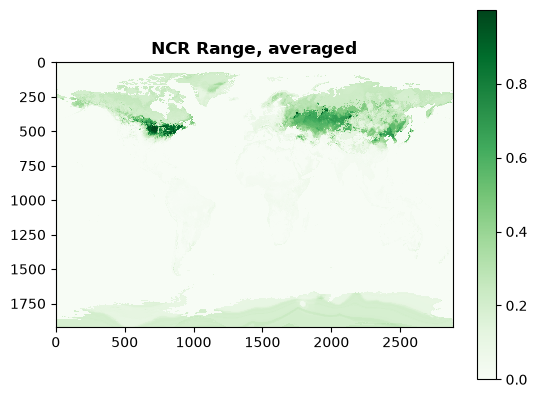

In [72]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

distr_rf = rasterio.open("outputs/rf1-images/probability_1.0.tif").read(1)
plotit(distr_rf, "NCR Range, averaged", cmap="Greens")